(1000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1000 non-null   str    
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   str    
 3   Tenure             1000 non-null   int64  
 4   MonthlyCharges     1000 non-null   float64
 5   TotalCharges       1000 non-null   float64
 6   Contract           1000 non-null   str    
 7   InternetService    653 non-null    str    
 8   TechSupport        1000 non-null   str    
 9   OnlineSecurity     1000 non-null   str    
 10  PaymentMethod      1000 non-null   str    
 11  SupportCalls       1000 non-null   int64  
 12  SatisfactionScore  1000 non-null   int64  
 13  Churn              1000 non-null   str    
dtypes: float64(2), int64(4), str(8)
memory usage: 109.5 KB
CustomerID             0
Age                    0
Gender          

C:\Users\POOJA A\AppData\Local\Temp\ipykernel_15460\427835337.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Accuracy : 0.99
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       124
           1       1.00      0.97      0.99        76

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200

[[124   0]
 [  2  74]]


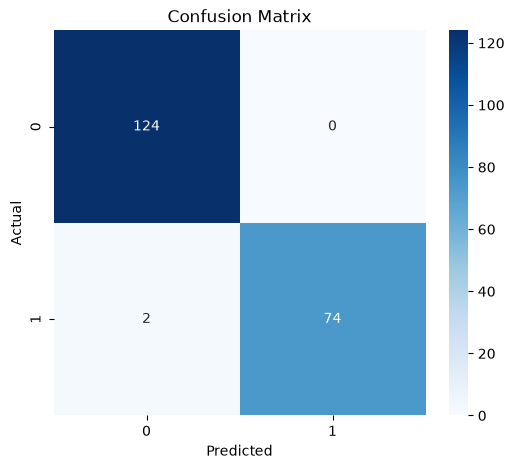

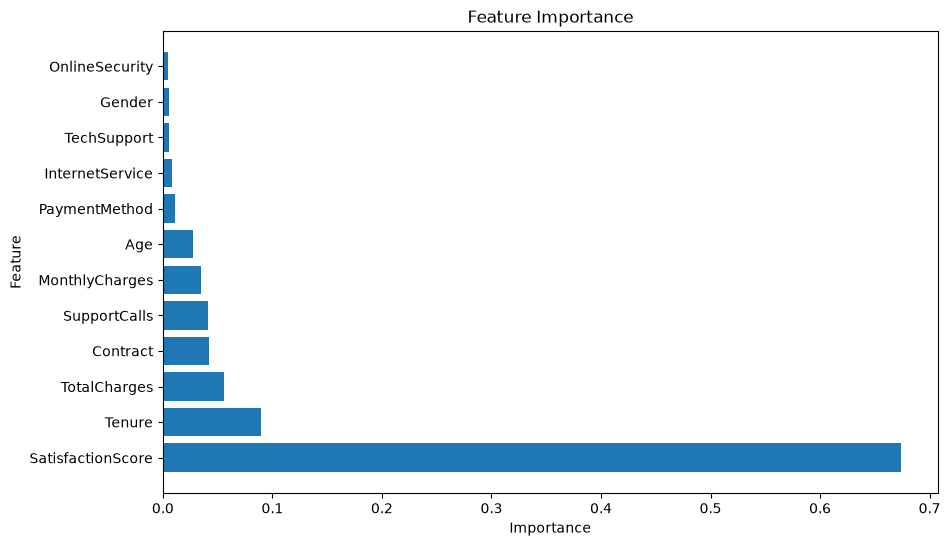

Prediction: 1


In [9]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv(r"C:\Users\POOJA A\OneDrive\Desktop\customer churn prediction\data\customer_churn_dataset_1000.csv")

print(df.shape)
df.info()
print(df.isnull().sum())

# Drop CustomerID if present
if "CustomerID" in df.columns:
    df.drop("CustomerID", axis=1, inplace=True)

# Encode categorical columns
label_encoders = {}
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    label_encoders[col] = encoder

# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Feature importance
importance = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.show()

# Save model and encoders
with open("../backend/churn_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("../backend/label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

# Test prediction on one sample
sample = X.iloc[[0]]
prediction = model.predict(sample)
print("Prediction:", prediction[0])
